<a href="https://colab.research.google.com/github/Ma7moud12975/3D-pose/blob/main/Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.flush_and_unmount()  # فصل الاتصال
drive.mount('/content/drive')  # إعادة الاتصال

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
print(os.listdir("/content/drive/MyDrive/archive/Training"))

['pituitary', 'meningioma', 'glioma', 'notumor']


In [ ]:
print(os.listdir("/content/drive/MyDrive/archive/Testing"))

['pituitary', 'glioma', 'notumor', 'meningioma']


In [ ]:
# تحديد المسار الرئيسي للبيانات
data_path = "/content/drive/MyDrive/archive/Training"

# جلب أسماء الفئات (أنواع الأورام) من المجلدات داخل المسار الرئيسي
tumor_classes = os.listdir(data_path)

# استعراض عدد الصور في كل فئة
for tumor in tumor_classes:
    tumor_path = os.path.join(data_path, tumor)
    num_images = len(os.listdir(tumor_path))
    print(f"{tumor}: {num_images} images")

pituitary: 1457 images
meningioma: 1339 images
glioma: 1321 images
notumor: 1595 images


In [ ]:
# تحديد المسار الرئيسي للبيانات
data_path = "/content/drive/MyDrive/archive/Testing"

# جلب أسماء الفئات (أنواع الأورام) من المجلدات داخل المسار الرئيسي
tumor_classes = os.listdir(data_path)

# استعراض عدد الصور في كل فئة
for tumor in tumor_classes:
    tumor_path = os.path.join(data_path, tumor)
    num_images = len(os.listdir(tumor_path))
    print(f"{tumor}: {num_images} images")

pituitary: 300 images
glioma: 300 images
notumor: 405 images
meningioma: 306 images


In [ ]:
from PIL import Image
import os

test_path = "/content/drive/MyDrive/archive/Training"  # غيّرت المسار من Training لـ Testing
tumor_classes = os.listdir(test_path)

for tumor in tumor_classes:
    tumor_path = os.path.join(test_path, tumor)
    images = os.listdir(tumor_path)

    print(f"\nCategory: {tumor}")

    for img_name in images[:5]:  # عرض أول 5 صور من كل فئة
        img_path = os.path.join(tumor_path, img_name)
        try:
            img = Image.open(img_path)  # تحميل الصورة بدون تدخل من TensorFlow
            print(f"Image: {img_name} | Mode: {img.mode} | Size: {img.size}")
        except Exception as e:
            print(f"Error loading {img_name}: {e}")


Category: pituitary
Image: Tr-pi_0350.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-pi_0565.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-pi_0662.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-pi_0617.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-pi_0214.jpg | Mode: RGB | Size: (512, 512)

Category: meningioma
Image: Tr-me_0302.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-me_0374.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-me_0311.jpg | Mode: RGB | Size: (512, 512)
Image: Tr-me_0213.jpg | Mode: RGB | Size: (513, 522)
Image: Tr-me_0453.jpg | Mode: RGB | Size: (512, 512)

Category: glioma
Image: Tr-gl_0270.jpg | Mode: L | Size: (512, 512)
Image: Tr-gl_0525.jpg | Mode: L | Size: (512, 512)
Image: Tr-gl_0482.jpg | Mode: L | Size: (512, 512)
Image: Tr-gl_0191.jpg | Mode: L | Size: (512, 512)
Image: Tr-gl_0602.jpg | Mode: L | Size: (512, 512)

Category: notumor
Image: Tr-no_0505.jpg | Mode: RGB | Size: (359, 449)
Image: Tr-no_0431.jpg | Mode: RGB | Size: (201, 250)
Image: Tr-no_0595.jpg | Mode:

In [ ]:
from PIL import Image
import os

test_path = "/content/drive/MyDrive/archive/Testing"  # غيّرت المسار من Training لـ Testing
tumor_classes = os.listdir(test_path)

for tumor in tumor_classes:
    tumor_path = os.path.join(test_path, tumor)
    images = os.listdir(tumor_path)

    print(f"\nCategory: {tumor}")

    for img_name in images[:5]:  # عرض أول 5 صور من كل فئة
        img_path = os.path.join(tumor_path, img_name)
        try:
            img = Image.open(img_path)  # تحميل الصورة بدون تدخل من TensorFlow
            print(f"Image: {img_name} | Mode: {img.mode} | Size: {img.size}")
        except Exception as e:
            print(f"Error loading {img_name}: {e}")


Category: pituitary
Image: Te-pi_0191.jpg | Mode: L | Size: (512, 512)
Image: Te-pi_0222.jpg | Mode: L | Size: (512, 512)
Image: Te-pi_0221.jpg | Mode: L | Size: (512, 512)
Image: Te-pi_0162.jpg | Mode: L | Size: (512, 512)
Image: Te-pi_0106.jpg | Mode: L | Size: (512, 512)

Category: glioma
Image: Te-glTr_0000.jpg | Mode: RGB | Size: (512, 512)
Image: Te-glTr_0001.jpg | Mode: RGB | Size: (512, 512)
Image: Te-glTr_0002.jpg | Mode: RGB | Size: (512, 512)
Image: Te-glTr_0004.jpg | Mode: RGB | Size: (512, 512)
Image: Te-glTr_0003.jpg | Mode: RGB | Size: (512, 512)

Category: notumor
Image: Te-no_0076.jpg | Mode: RGB | Size: (235, 229)
Image: Te-no_0039.jpg | Mode: RGB | Size: (236, 300)
Image: Te-no_0042.jpg | Mode: RGB | Size: (208, 225)
Image: Te-no_0058.jpg | Mode: RGB | Size: (236, 236)
Image: Te-no_0062.jpg | Mode: RGB | Size: (236, 262)

Category: meningioma
Image: Te-me_0277.jpg | Mode: L | Size: (512, 512)
Image: Te-me_0301.jpg | Mode: L | Size: (512, 512)
Image: Te-me_0101.jpg |

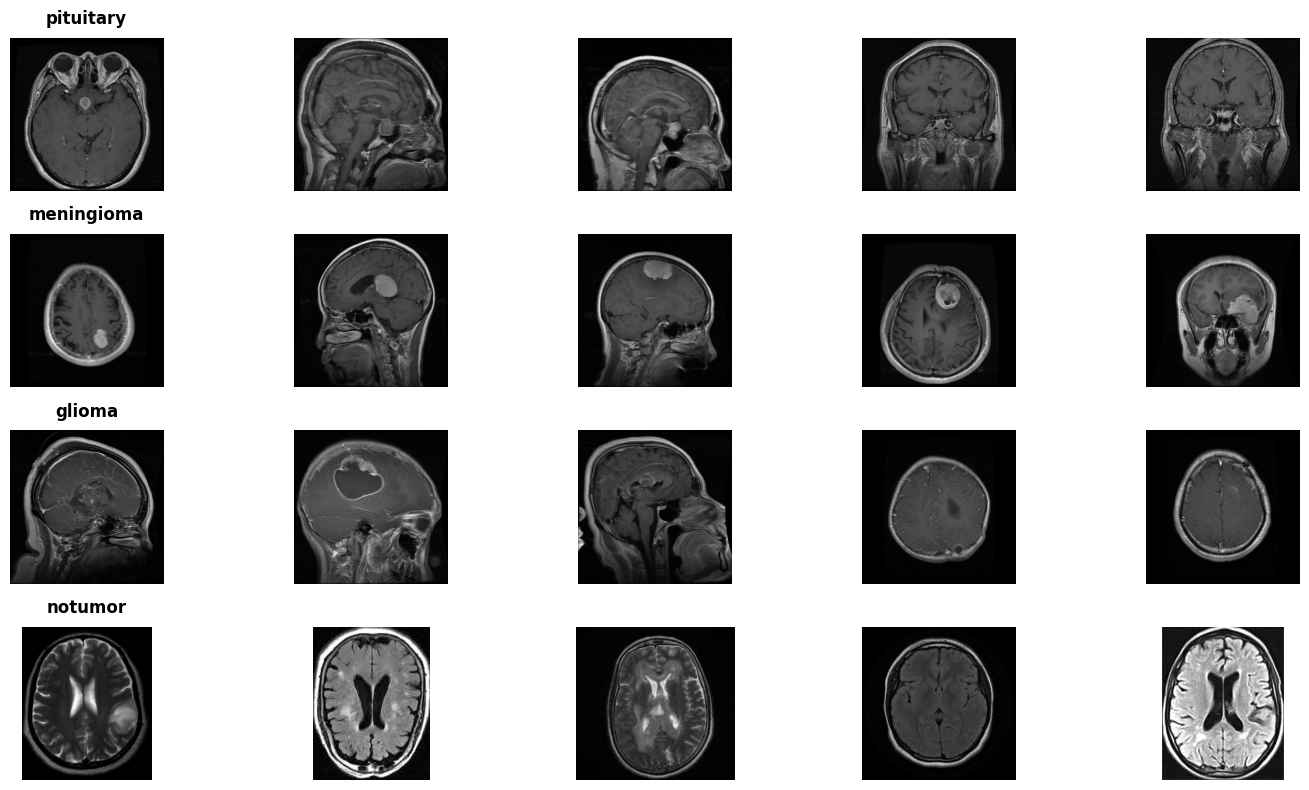

In [ ]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# مسار مجلد الـ Training
train_path = "/content/drive/MyDrive/archive/Training"

# جلب أسماء الفئات
tumor_classes = os.listdir(train_path)

# إنشاء شكل للعرض
fig, axes = plt.subplots(len(tumor_classes), 5, figsize=(15, 8))

# عرض 5 صور عشوائية من كل فئة
for i, tumor in enumerate(tumor_classes):
    tumor_path = os.path.join(train_path, tumor)
    images = os.listdir(tumor_path)  # جلب جميع الصور في المجلد
    sample_images = random.sample(images, 5)  # اختيار 5 صور عشوائية

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(tumor_path, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)  # تحميل الصورة باستخدام TensorFlow

        axes[i, j].imshow(img, cmap="gray")  # عرض الصورة باللون الرمادي
        axes[i, j].axis("off")

    # إضافة العنوان فوق أول صورة فقط لكل فئة
    axes[i, 0].set_title(tumor, fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

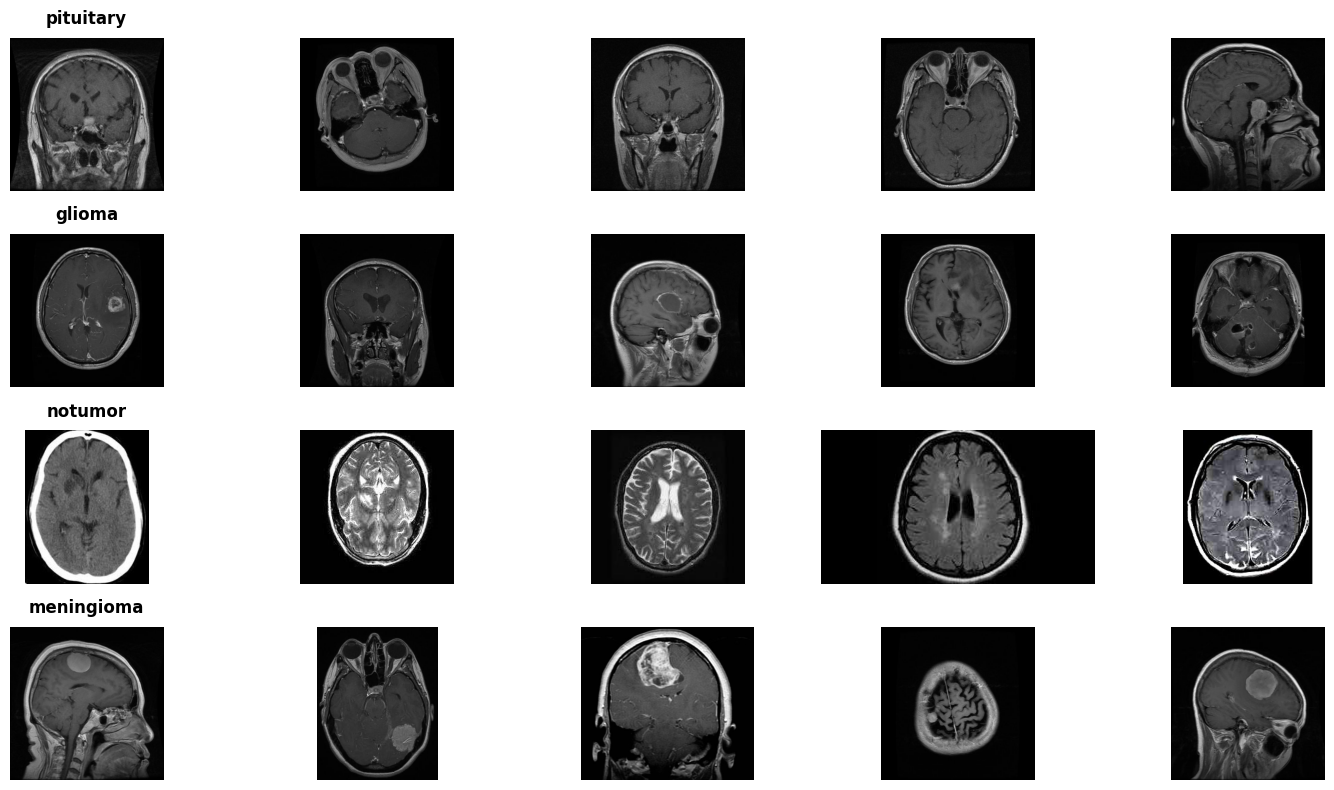

In [ ]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# مسار مجلد الـ Testing
test_path = "/content/drive/MyDrive/archive/Testing"

# جلب أسماء الفئات
tumor_classes = os.listdir(test_path)

# إنشاء شكل للعرض
fig, axes = plt.subplots(len(tumor_classes), 5, figsize=(15, 8))

# عرض 5 صور عشوائية من كل فئة
for i, tumor in enumerate(tumor_classes):
    tumor_path = os.path.join(test_path, tumor)
    images = os.listdir(tumor_path)  # جلب جميع الصور في المجلد
    sample_images = random.sample(images, 5)  # اختيار 5 صور عشوائية

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(tumor_path, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)  # تحميل الصورة باستخدام TensorFlow

        axes[i, j].imshow(img, cmap="gray")  # عرض الصورة باللون الرمادي
        axes[i, j].axis("off")

    # إضافة العنوان فوق أول صورة فقط لكل فئة
    axes[i, 0].set_title(tumor, fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

In [ ]:
import os
import tensorflow as tf

# المسارات
train_path = "/content/drive/MyDrive/archive/Training"
output_path = "/content/drive/MyDrive/archive/Processed_Training"

# إنشاء الفولدر الجديد لو مش موجود
os.makedirs(output_path, exist_ok=True)

# توحيد الحجم
img_size = (299,299)

# جلب الفئات
tumor_classes = os.listdir(train_path)

for tumor in tumor_classes:
    tumor_path = os.path.join(train_path, tumor)
    output_tumor_path = os.path.join(output_path, tumor)

    os.makedirs(output_tumor_path, exist_ok=True)  # إنشاء فولدر الفئة في المسار الجديد

    for img_name in os.listdir(tumor_path):
        img_path = os.path.join(tumor_path, img_name)

        # تحميل الصورة باستخدام TensorFlow
        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=3)  # تحميل الصورة وتحويلها لـ RGB

        # تحويل الصورة إلى RGB لو كانت Grayscale
        if img.shape[-1] == 1:
            img = tf.image.grayscale_to_rgb(img)

        # توحيد الحجم
        img = tf.image.resize(img, img_size)

        # حفظ الصورة في المسار الجديد
        tf.keras.preprocessing.image.save_img(os.path.join(output_tumor_path, img_name), img)

print("✅ Processing done! All images are saved in:", output_path)

✅ Processing done! All images are saved in: /content/drive/MyDrive/archive/Processed_Training


In [ ]:
import os
import tensorflow as tf

# المسارات
test_path = "/content/drive/MyDrive/archive/Testing"
output_path = "/content/drive/MyDrive/archive/Processed_Testing"

# إنشاء الفولدر الجديد لو مش موجود
os.makedirs(output_path, exist_ok=True)

# توحيد الحجم
img_size = (299,299)

# جلب الفئات
tumor_classes = os.listdir(test_path)

for tumor in tumor_classes:
    tumor_path = os.path.join(test_path, tumor)
    output_tumor_path = os.path.join(output_path, tumor)

    os.makedirs(output_tumor_path, exist_ok=True)  # إنشاء فولدر الفئة في المسار الجديد

    for img_name in os.listdir(tumor_path):
        img_path = os.path.join(tumor_path, img_name)

        # تحميل الصورة باستخدام TensorFlow
        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=3)  # تحميل الصورة وتحويلها لـ RGB

        # تحويل الصورة إلى RGB لو كانت Grayscale
        if img.shape[-1] == 1:
            img = tf.image.grayscale_to_rgb(img)

        # توحيد الحجم
        img = tf.image.resize(img, img_size)

        # حفظ الصورة في المسار الجديد
        tf.keras.preprocessing.image.save_img(os.path.join(output_tumor_path, img_name), img)

print("✅ Processing done! All images are saved in:", output_path)

✅ Processing done! All images are saved in: /content/drive/MyDrive/archive/Processed_Testing


In [ ]:
import tensorflow as tf
import os

# تحديد المسار لمجلد الـ Processed Training
processed_train_path = "/content/drive/MyDrive/archive/Processed_Training"

# جلب أسماء الفئات
tumor_classes = os.listdir(processed_train_path)

# التحقق من نوع الصور في كل فئة
for tumor in tumor_classes:
    tumor_path = os.path.join(processed_train_path, tumor)
    images = os.listdir(tumor_path)

    print(f"\nCategory: {tumor}")  # طباعة اسم الفئة

    for img_name in images[:5]:  # فحص أول 5 صور فقط من كل فئة
        img_path = os.path.join(tumor_path, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)  # تحميل الصورة باستخدام TensorFlow
        print(f"Image: {img_name} | Mode: {img.mode} | Size: {img.size}")


Category: pituitary
Image: Tr-pi_0350.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-pi_0565.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-pi_0662.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-pi_0617.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-pi_0214.jpg | Mode: RGB | Size: (299, 299)

Category: meningioma
Image: Tr-me_0302.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-me_0374.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-me_0311.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-me_0213.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-me_0453.jpg | Mode: RGB | Size: (299, 299)

Category: glioma
Image: Tr-gl_0270.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-gl_0525.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-gl_0482.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-gl_0191.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-gl_0602.jpg | Mode: RGB | Size: (299, 299)

Category: notumor
Image: Tr-no_0505.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-no_0431.jpg | Mode: RGB | Size: (299, 299)
Image: Tr-no_0595.j

In [ ]:
import tensorflow as tf
import os

# تحديد المسار لمجلد الـ Processed Testing
processed_test_path = "/content/drive/MyDrive/archive/Processed_Testing"

# جلب أسماء الفئات
tumor_classes = os.listdir(processed_test_path)

# التحقق من نوع الصور في كل فئة
for tumor in tumor_classes:
    tumor_path = os.path.join(processed_test_path, tumor)
    images = os.listdir(tumor_path)

    print(f"\nCategory: {tumor}")  # طباعة اسم الفئة

    for img_name in images[:5]:  # فحص أول 5 صور فقط من كل فئة
        img_path = os.path.join(tumor_path, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path)  # تحميل الصورة باستخدام TensorFlow
        print(f"Image: {img_name} | Mode: {img.mode} | Size: {img.size}")


Category: pituitary
Image: Te-pi_0191.jpg | Mode: RGB | Size: (299, 299)
Image: Te-pi_0222.jpg | Mode: RGB | Size: (299, 299)
Image: Te-pi_0221.jpg | Mode: RGB | Size: (299, 299)
Image: Te-pi_0162.jpg | Mode: RGB | Size: (299, 299)
Image: Te-pi_0106.jpg | Mode: RGB | Size: (299, 299)

Category: glioma
Image: Te-glTr_0000.jpg | Mode: RGB | Size: (299, 299)
Image: Te-glTr_0001.jpg | Mode: RGB | Size: (299, 299)
Image: Te-glTr_0002.jpg | Mode: RGB | Size: (299, 299)
Image: Te-glTr_0004.jpg | Mode: RGB | Size: (299, 299)
Image: Te-glTr_0003.jpg | Mode: RGB | Size: (299, 299)

Category: notumor
Image: Te-no_0076.jpg | Mode: RGB | Size: (299, 299)
Image: Te-no_0039.jpg | Mode: RGB | Size: (299, 299)
Image: Te-no_0042.jpg | Mode: RGB | Size: (299, 299)
Image: Te-no_0058.jpg | Mode: RGB | Size: (299, 299)
Image: Te-no_0062.jpg | Mode: RGB | Size: (299, 299)

Category: meningioma
Image: Te-me_0277.jpg | Mode: RGB | Size: (299, 299)
Image: Te-me_0301.jpg | Mode: RGB | Size: (299, 299)
Image: Te

In [ ]:
import tensorflow as tf
import os

# مسار فولدر الاختبار
test_dir = "/content/drive/MyDrive/archive/Processed_Training"  # استبدليه بمسار الفولدر عندك

def enhance_and_save(image_path):
    """ تحسين جودة الصورة وحفظها بنفس الاسم باستخدام TensorFlow """
    # تحميل الصورة
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, dtype=tf.float32)  # تحويل الصورة لـ float32

    # تحسين التباين والإضاءة
    image = tf.image.adjust_contrast(image, 2.0)
    image = tf.image.adjust_brightness(image, 0.05)  # زيادة الإضاءة قليلاً
    image = tf.image.per_image_standardization(image)  # توحيد توزيع البكسلات

    # استخراج الحواف باستخدام Sobel Filter
    sobel_edges = tf.image.sobel_edges(tf.expand_dims(image, axis=0))
    sobel_edges = tf.reduce_mean(tf.abs(sobel_edges), axis=-1)  # تحويلها لقناة واحدة
    sobel_edges = tf.image.convert_image_dtype(sobel_edges, tf.float32)  # تطبيع القيم

    # دمج الحواف مع الصورة الأصلية
    sharpened = image + (sobel_edges * 0.5)  # تقوية الحواف ولكن بنسبة 50% فقط

    # التأكد من أن القيم داخل النطاق الصحيح
    final_img = tf.clip_by_value(sharpened, 0, 1)  # القيم بين 0 و 1
    final_img = tf.image.convert_image_dtype(final_img, tf.uint8)  # تحويلها لـ uint8

    # حفظ الصورة بنفس الاسم لاستبدالها
    encoded_img = tf.io.encode_jpeg(final_img, quality=95)  # جودة عالية
    tf.io.write_file(image_path, encoded_img)

# تطبيق التحسين على كل الصور في فولدر الاختبار
for img_name in os.listdir(test_dir):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(test_dir, img_name)
        enhance_and_save(img_path)

print("✅ Image enhancement for test set completed successfully!")

✅ Image enhancement for test set completed successfully!


In [ ]:
import tensorflow as tf
import os

# مسار فولدر الاختبار
test_dir = "/content/drive/MyDrive/archive/Processed_Testing"  # استبدليه بمسار الفولدر عندك

def enhance_and_save(image_path):
    """ تحسين جودة الصورة وحفظها بنفس الاسم باستخدام TensorFlow """
    # تحميل الصورة
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, dtype=tf.float32)  # تحويل الصورة لـ float32

    # تحسين التباين والإضاءة
    image = tf.image.adjust_contrast(image, 2.0)
    image = tf.image.adjust_brightness(image, 0.05)  # زيادة الإضاءة قليلاً
    image = tf.image.per_image_standardization(image)  # توحيد توزيع البكسلات

    # استخراج الحواف باستخدام Sobel Filter
    sobel_edges = tf.image.sobel_edges(tf.expand_dims(image, axis=0))
    sobel_edges = tf.reduce_mean(tf.abs(sobel_edges), axis=-1)  # تحويلها لقناة واحدة
    sobel_edges = tf.image.convert_image_dtype(sobel_edges, tf.float32)  # تطبيع القيم

    # دمج الحواف مع الصورة الأصلية
    sharpened = image + (sobel_edges * 0.5)  # تقوية الحواف ولكن بنسبة 50% فقط

    # التأكد من أن القيم داخل النطاق الصحيح
    final_img = tf.clip_by_value(sharpened, 0, 1)  # القيم بين 0 و 1
    final_img = tf.image.convert_image_dtype(final_img, tf.uint8)  # تحويلها لـ uint8

    # حفظ الصورة بنفس الاسم لاستبدالها
    encoded_img = tf.io.encode_jpeg(final_img, quality=95)  # جودة عالية
    tf.io.write_file(image_path, encoded_img)

# تطبيق التحسين على كل الصور في فولدر الاختبار
for img_name in os.listdir(test_dir):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(test_dir, img_name)
        enhance_and_save(img_path)

print("✅ Image enhancement for test set completed successfully!")

✅ Image enhancement for test set completed successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# المسارات الخاصة بالبيانات
training_dir = "/content/drive/MyDrive/archive/Processed_Training"
test_dir = "/content/drive/MyDrive/archive/Processed_Testing"

# إعداد الـ ImageDataGenerator مع تطبيق النورماليزيشن الصحيح لـ Xception
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input  # تطبيق نورماليزيشن Xception
)

# إعداد البيانات للتدريب
train_data_gen = datagen.flow_from_directory(
    training_dir,
    target_size=(299,299),
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

# إعداد البيانات للتست
test_data_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(299,299),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

# التأكد من أن النورماليزيشن تم بشكل صحيح
x_batch, y_batch = next(train_data_gen)

print(f"✅ Normalization for Xception has been applied successfully!")
print(f" Min value of the batch: {x_batch.min()}")
print(f" Max value of the batch: {x_batch.max()}")

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
✅ Normalization for Xception has been applied successfully!
 Min value of the batch: -1.0
 Max value of the batch: 1.0


In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Training"

# تحميل الصور وتحويلها إلى Tensors
def load_images(data_path):
    images = []
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1
            images.append(img)
    return images

# تحميل الصور
images = load_images(data_path)

# حساب الـ outliers
outlier_count = 0
total_pixels = 0

for img in images:
    img_array = img.numpy().flatten()  # تحويل الصورة إلى مصفوفة 1D
    mean, std = np.mean(img_array), np.std(img_array)  # حساب المتوسط والانحراف المعياري

    # تحديد القيم الشاذة خارج نطاق [mean - 3*std, mean + 3*std]
    outliers = (img_array < mean - 3 * std) | (img_array > mean + 3 * std)
    outlier_count += np.sum(outliers)  # عدّ البكسلات الشاذة
    total_pixels += img_array.size  # إجمالي عدد البكسلات

# حساب نسبة الـ outliers
outlier_percentage = (outlier_count / total_pixels) * 100

print(f"Total pixels: {total_pixels}")
print(f"Number of outlier pixels: {outlier_count}")
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

Total pixels: 1531975536
Number of outlier pixels: 15881770
Percentage of outliers: 1.04%


In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Testing"

# تحميل الصور وتحويلها إلى Tensors
def load_images(data_path):
    images = []
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1
            images.append(img)
    return images

# تحميل الصور
images = load_images(data_path)

# حساب الـ outliers
outlier_count = 0
total_pixels = 0

for img in images:
    img_array = img.numpy().flatten()  # تحويل الصورة إلى مصفوفة 1D
    mean, std = np.mean(img_array), np.std(img_array)  # حساب المتوسط والانحراف المعياري

    # تحديد القيم الشاذة خارج نطاق [mean - 3*std, mean + 3*std]
    outliers = (img_array < mean - 3 * std) | (img_array > mean + 3 * std)
    outlier_count += np.sum(outliers)  # عدّ البكسلات الشاذة
    total_pixels += img_array.size  # إجمالي عدد البكسلات

# حساب نسبة الـ outliers
outlier_percentage = (outlier_count / total_pixels) * 100

print(f"Total pixels: {total_pixels}")
print(f"Number of outlier pixels: {outlier_count}")
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

Total pixels: 351614133
Number of outlier pixels: 3385867
Percentage of outliers: 0.96%


In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Training"

# تحميل الصور وحساب متوسط سطوعها
def load_images_brightness(data_path):
    brightness_values = []
    image_paths = []

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1

            brightness = tf.reduce_mean(img).numpy()  # حساب متوسط السطوع
            brightness_values.append(brightness)
            image_paths.append(img_path)

    return brightness_values, image_paths

# تحميل الصور وحساب متوسط السطوع لكل صورة
brightness_values, image_paths = load_images_brightness(data_path)

# حساب المتوسط والانحراف المعياري للسطوع
mean_brightness = np.mean(brightness_values)
std_brightness = np.std(brightness_values)

# تحديد الصور الشاذة
outlier_images = []
for i, brightness in enumerate(brightness_values):
    if brightness < mean_brightness - 3 * std_brightness or brightness > mean_brightness + 3 * std_brightness:
        outlier_images.append(image_paths[i])

# طباعة النتائج
print(f"Total images: {len(image_paths)}")
print(f"Number of outlier images: {len(outlier_images)}")
print("Outlier images:")
for img in outlier_images:
    print(img)

Total images: 5712
Number of outlier images: 71
Outlier images:
/content/drive/MyDrive/archive/Processed_Training/pituitary/Tr-pi_0038.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0247.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0191.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0185.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0180.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0202.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0261.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0592.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0588.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0367.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0178.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0359.jpg
/content/drive/MyDrive/ar

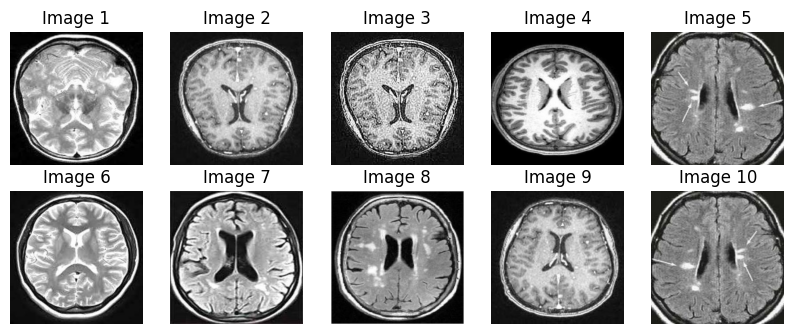

In [ ]:
import matplotlib.pyplot as plt
import cv2

# قائمة الصور الشاذة
outlier_images = [
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0185.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0180.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0359.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0247.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0261.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0592.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0588.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0262.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0367.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0267.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0191.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0275.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0202.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0178.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/pituitary/Tr-pi_0038.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0508.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0491.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0506.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0661.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0842.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0640.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1050.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0450.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0790.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1062.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0638.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1060.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0767.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0686.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0688.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0636.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0859.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0366.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0986.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1536.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1286.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1094.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1308.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1315.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1335.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1144.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1203.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1213.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1244.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1339.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1310.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0131.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0216.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0124.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0117.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0071.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0215.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0354.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0628.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0860.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0369.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0441.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0874.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0387.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0777.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0648.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0466.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0675.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0527.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0762.jpg"
]

# عرض أول 10 صور شاذة
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(outlier_images[30:40]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Testing"

# تحميل الصور وحساب متوسط سطوعها
def load_images_brightness(data_path):
    brightness_values = []
    image_paths = []

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1

            brightness = tf.reduce_mean(img).numpy()  # حساب متوسط السطوع
            brightness_values.append(brightness)
            image_paths.append(img_path)

    return brightness_values, image_paths

# تحميل الصور وحساب متوسط السطوع لكل صورة
brightness_values, image_paths = load_images_brightness(data_path)

# حساب المتوسط والانحراف المعياري للسطوع
mean_brightness = np.mean(brightness_values)
std_brightness = np.std(brightness_values)

# تحديد الصور الشاذة
outlier_images = []
for i, brightness in enumerate(brightness_values):
    if brightness < mean_brightness - 3 * std_brightness or brightness > mean_brightness + 3 * std_brightness:
        outlier_images.append(image_paths[i])

# طباعة النتائج
print(f"Total images: {len(image_paths)}")
print(f"Number of outlier images: {len(outlier_images)}")
print("Outlier images:")
for img in outlier_images:
    print(img)

Total images: 1311
Number of outlier images: 18
Outlier images:
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0118.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0090.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0286.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0176.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0289.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0250.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0280.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0294.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0399.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0271.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0166.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0377.jpg
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0328.jpg


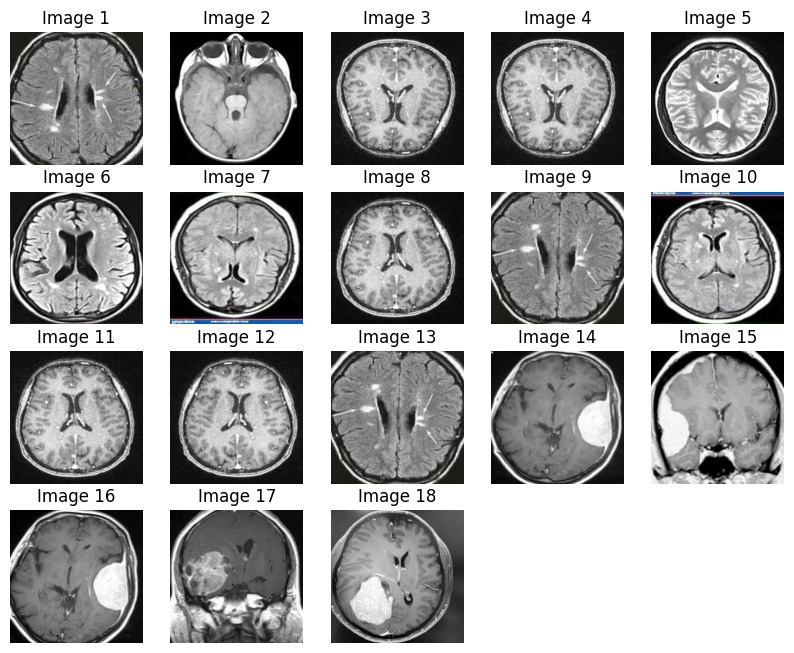

In [ ]:
import matplotlib.pyplot as plt
import cv2

# قائمة الصور الشاذة
outlier_images = [
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0118.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0090.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0286.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0176.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0289.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0250.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0280.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0294.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0399.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0271.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0166.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0377.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0328.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0098.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0069.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0012.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0022.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0090.jpg"
]

# عرض أول 10 صور شاذة
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(outlier_images[:18]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# قائمة الصور الشاذة (انسخي اللي عندك مكان دي)
outlier_images = [
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0185.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0180.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0359.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0247.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0261.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0592.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0588.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0262.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0367.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0267.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0191.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0275.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0202.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0178.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/pituitary/Tr-pi_0038.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0508.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0491.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0506.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0661.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0842.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0640.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1050.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0450.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0790.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1062.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0638.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1060.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0767.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0686.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0688.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0636.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0859.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0366.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0986.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1536.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1286.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1094.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1308.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1315.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1335.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1144.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1203.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1213.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1244.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1339.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1310.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0131.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0216.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0124.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0117.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0071.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0215.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0354.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0628.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0860.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0369.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0441.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0874.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0387.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0777.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0648.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0466.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0675.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0527.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0762.jpg"
]

# القيمة المتوسطة العامة للسطوع (اللي حسبتيها قبل كده)
mean_brightness = np.mean([0.21])  # استبدلي 0.21 بالقيمة اللي حسبتيها في كودك السابق

def correct_brightness(image_path, target_brightness):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    current_brightness = tf.reduce_mean(img).numpy()
    delta = target_brightness - current_brightness  # الفرق بين المطلوب والحالي

    adjusted_img = tf.image.adjust_brightness(img, delta)

    # تأكد من أن القيم بين 0 و 1
    adjusted_img = tf.clip_by_value(adjusted_img, 0.0, 1.0)

    # تحويل لـ uint8 وحفظ
    adjusted_img_uint8 = tf.image.convert_image_dtype(adjusted_img, tf.uint8)
    encoded_img = tf.io.encode_jpeg(adjusted_img_uint8)
    tf.io.write_file(image_path, encoded_img)

# نطبق التعديل على كل الصور الشاذة
for img_path in outlier_images:
    correct_brightness(img_path, mean_brightness)

print("✅ Brightness of outlier images has been successfully adjusted!")

✅ Brightness of outlier images has been successfully adjusted!


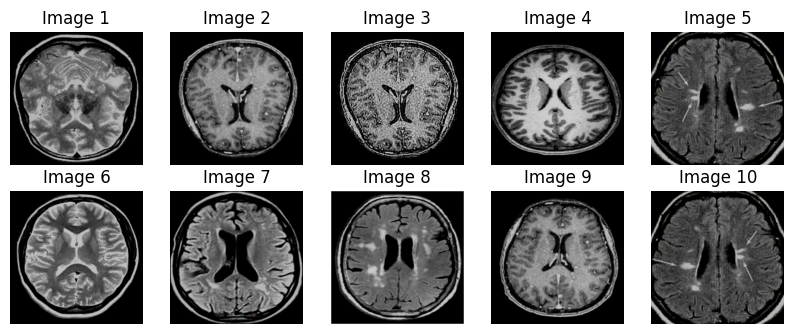

In [ ]:
import matplotlib.pyplot as plt
import cv2

# قائمة الصور الشاذة
outlier_images = [
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0185.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0180.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0359.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0247.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0261.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0592.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0588.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0262.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0367.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0267.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0191.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0275.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0202.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0178.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/pituitary/Tr-pi_0038.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0508.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0491.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0506.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0661.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0842.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0640.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1050.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0450.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0790.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1062.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0638.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1060.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0767.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0686.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0688.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0636.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0859.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0366.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0986.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1536.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1286.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1094.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1308.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1396.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1315.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1335.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1144.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1203.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1213.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1244.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1339.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_1310.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0131.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0095.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0216.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0124.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0117.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0071.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0248.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0215.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0354.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0628.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0860.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0369.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0441.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0874.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0387.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0777.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0648.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0466.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0675.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0527.jpg",
    "/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0762.jpg"
]

# عرض أول 10 صور شاذة
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(outlier_images[30:40]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# قائمة الصور الشاذة (انسخي اللي عندك مكان دي)
outlier_images = [
   "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0118.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0090.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0286.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0176.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0289.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0250.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0280.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0294.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0399.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0271.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0166.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0377.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0328.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0098.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0069.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0012.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0022.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0090.jpg"
]

# القيمة المتوسطة العامة للسطوع (اللي حسبتيها قبل كده)
mean_brightness = np.mean([0.21])  # استبدلي 0.21 بالقيمة اللي حسبتيها في كودك السابق

def correct_brightness(image_path, target_brightness):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    current_brightness = tf.reduce_mean(img).numpy()
    delta = target_brightness - current_brightness  # الفرق بين المطلوب والحالي

    adjusted_img = tf.image.adjust_brightness(img, delta)

    # تأكد من أن القيم بين 0 و 1
    adjusted_img = tf.clip_by_value(adjusted_img, 0.0, 1.0)

    # تحويل لـ uint8 وحفظ
    adjusted_img_uint8 = tf.image.convert_image_dtype(adjusted_img, tf.uint8)
    encoded_img = tf.io.encode_jpeg(adjusted_img_uint8)
    tf.io.write_file(image_path, encoded_img)

# نطبق التعديل على كل الصور الشاذة
for img_path in outlier_images:
    correct_brightness(img_path, mean_brightness)

print("✅ Brightness of outlier images has been successfully adjusted!")

✅ Brightness of outlier images has been successfully adjusted!


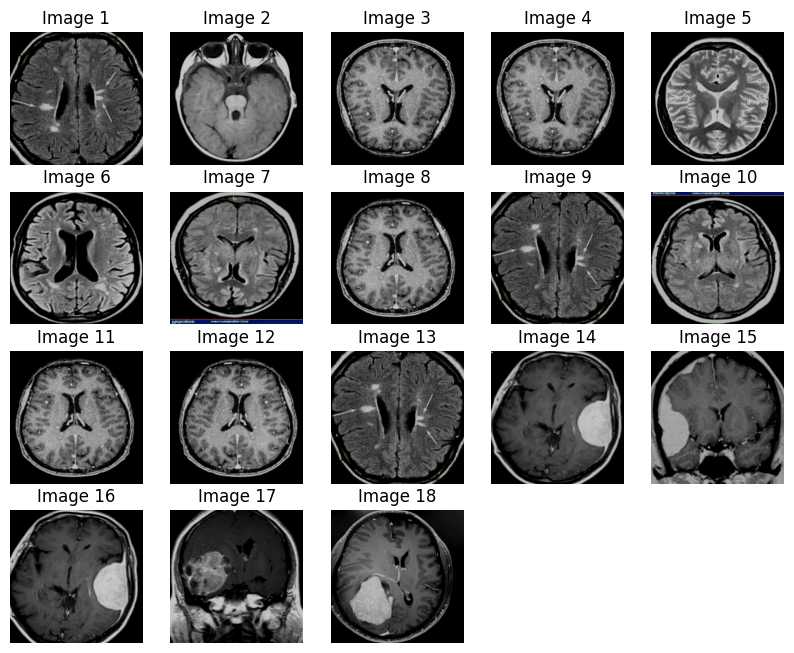

In [ ]:
import matplotlib.pyplot as plt
import cv2

# قائمة الصور الشاذة
outlier_images = [
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0118.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0090.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0286.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0176.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0289.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0250.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0280.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0294.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0399.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0271.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0166.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0377.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0328.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0098.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0069.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0012.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0022.jpg",
    "/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0090.jpg"
]

# عرض أول 10 صور شاذة
plt.figure(figsize=(10, 10))
for i, img_path in enumerate(outlier_images[:18]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Training"

# تحميل الصور وحساب متوسط سطوعها
def load_images_brightness(data_path):
    brightness_values = []
    image_paths = []

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1

            brightness = tf.reduce_mean(img).numpy()  # حساب متوسط السطوع
            brightness_values.append(brightness)
            image_paths.append(img_path)

    return brightness_values, image_paths

# تحميل الصور وحساب متوسط السطوع لكل صورة
brightness_values, image_paths = load_images_brightness(data_path)

# حساب المتوسط والانحراف المعياري للسطوع
mean_brightness = np.mean(brightness_values)
std_brightness = np.std(brightness_values)

# تحديد الصور الشاذة
outlier_images = []
for i, brightness in enumerate(brightness_values):
    if brightness < mean_brightness - 3 * std_brightness or brightness > mean_brightness + 3 * std_brightness:
        outlier_images.append(image_paths[i])

# طباعة النتائج
print(f"Total images: {len(image_paths)}")
print(f"Number of outlier images: {len(outlier_images)}")
print("Outlier images:")
for img in outlier_images:
    print(img)

Total images: 5712
Number of outlier images: 35
Outlier images:
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0362.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0252.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0225.jpg
/content/drive/MyDrive/archive/Processed_Training/meningioma/Tr-me_0364.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0911.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0847.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0813.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0644.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0779.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0662.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0596.jpg
/content/drive/MyDrive/archive/Processed_Training/notumor/Tr-no_0829.jpg
/content/drive/MyDrive/archive/Processed_Trainin

In [ ]:
import tensorflow as tf
import numpy as np
import os

# مسار فولدر البيانات
data_path = "/content/drive/MyDrive/archive/Processed_Testing"

# تحميل الصور وحساب متوسط سطوعها
def load_images_brightness(data_path):
    brightness_values = []
    image_paths = []

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)  # تحميل الصورة
            img = tf.image.convert_image_dtype(img, tf.float32)  # تحويل القيم بين 0 و 1

            brightness = tf.reduce_mean(img).numpy()  # حساب متوسط السطوع
            brightness_values.append(brightness)
            image_paths.append(img_path)

    return brightness_values, image_paths

# تحميل الصور وحساب متوسط السطوع لكل صورة
brightness_values, image_paths = load_images_brightness(data_path)

# حساب المتوسط والانحراف المعياري للسطوع
mean_brightness = np.mean(brightness_values)
std_brightness = np.std(brightness_values)

# تحديد الصور الشاذة
outlier_images = []
for i, brightness in enumerate(brightness_values):
    if brightness < mean_brightness - 3 * std_brightness or brightness > mean_brightness + 3 * std_brightness:
        outlier_images.append(image_paths[i])

# طباعة النتائج
print(f"Total images: {len(image_paths)}")
print(f"Number of outlier images: {len(outlier_images)}")
print("Outlier images:")
for img in outlier_images:
    print(img)

Total images: 1311
Number of outlier images: 4
Outlier images:
/content/drive/MyDrive/archive/Processed_Testing/notumor/Te-no_0039.jpg
/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0084.jpg
/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0070.jpg
/content/drive/MyDrive/archive/Processed_Testing/meningioma/Te-me_0085.jpg


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, concatenate, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K

base_dir = '/content/drive/MyDrive/archive'
sub_dirs = ['Training', 'Testing']
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Function to load and preprocess thhe images
def load_images(base_dir, sub_dirs, categories, target_size=(128, 128)):
    images = []
    masks = []
    for sub_dir in sub_dirs:
        for category in categories:
            category_path = os.path.join(base_dir, sub_dir, category)
            img_files = os.listdir(category_path)
            for img_file in img_files:
                img_path = os.path.join(category_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, target_size)
                mask = np.zeros_like(img)
                mask[img > 0] = 1  # Binary mask for tumor
                img = img / 255.0
                images.append(img)
                masks.append(mask)
    return np.array(images), np.array(masks)


images, masks = load_images(base_dir, sub_dirs, categories)

# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)

In [ ]:

# Reshape data for U-Net
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
y_train = y_train[..., np.newaxis]
y_test = y_test[..., np.newaxis]


def unet(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(64, 3, activation='relu', padding='same')(pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(128, 3, activation='relu', padding='same')(pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(256, 3, activation='relu', padding='same')(pool3)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)
    conv5 = Conv2D(512, 3, activation='relu', padding='same')(pool4)
    drop5 = Dropout(0.5)(conv5)
    up6 = Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(drop5)
    up6 = concatenate([up6, conv4], axis=3)
    conv6 = Conv2D(256, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, 3, activation='relu', padding='same')(conv6)
    up7 = Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv6)
    up7 = concatenate([up7, conv3], axis=3)
    conv7 = Conv2D(128, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, 3, activation='relu', padding='same')(conv7)
    up8 = Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv7)
    up8 = concatenate([up8, conv2], axis=3)
    conv8 = Conv2D(64, 3, activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, 3, activation='relu', padding='same')(conv8)
    up9 = Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv8)
    up9 = concatenate([up9, conv1], axis=3)
    conv9 = Conv2D(32, 3, activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, 3, activation='relu', padding='same')(conv9)
    outputs = Conv2D(1, 1, activation='sigmoid')(conv9)
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = unet(input_size=(128, 128, 1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8, 8, 512) │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ dropout_1[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    131,200 │ conv2d_6[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,615,873 (17.61 MB)

 Trainable params: 4,615,873 (17.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

checkpoint = ModelCheckpoint('unet_brain_segmentation.keras', monitor='val_loss', save_best_only=True, verbose=1)
callbacks = [checkpoint]

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64, callbacks=callbacks)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"test loss: {loss:.4f}, test Accuracy: {accuracy:.4f}")

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8007 - loss: 0.5374
Epoch 1: val_loss improved from inf to 0.23323, saving model to unet_brain_segmentation.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 85s 618ms/step - accuracy: 0.8012 - loss: 0.5357 - val_accuracy: 0.8560 - val_loss: 0.2332
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8843 - loss: 0.2170
Epoch 2: val_loss improved from 0.23323 to 0.13286, saving model to unet_brain_segmentation.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.8847 - loss: 0.2166 - val_accuracy: 0.9445 - val_loss: 0.1329
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9584 - loss: 0.1015
Epoch 3: val_loss improved from 0.13286 to 0.07685, saving model to unet_brain_segmentation.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step - accuracy: 0.9584 - loss: 0.1014 - val_accuracy: 0.9677 - val_loss: 0.0769
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9720 - loss: 0.0708
Epoch 4: val

In [ ]:
# توقّعات الموديل
preds = model.predict(X_test)
preds_binary = (preds > 0.5).astype(np.uint8)

# اختيار صورة عشوائية للعرض
idx = random.randint(0, len(X_test) - 1)

# عرض الصورة + الماسك الحقيقي + الماسك المتوقع
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(X_test[idx].squeeze(), cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Ground Truth Mask')
plt.imshow(y_test[idx].squeeze(), cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Predicted Mask')
plt.imshow(preds_binary[idx].squeeze(), cmap='gray')

plt.tight_layout()
plt.show()

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "xception" is incompatible with the layer: expected shape=(None, 299, 299, 3), found shape=(32, 128, 128)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 128, 128, 1), dtype=float32)
  • training=False
  • mask=None

In [ ]:
import os
import shutil
import random

# المسارات
train_dir = "/content/drive/MyDrive/archive/Processed_Training"
val_dir = "/content/drive/MyDrive/archive/Processed_Validation"

# إنشاء مجلد التحقق (لو مش موجود)
os.makedirs(val_dir, exist_ok=True)

# نسبة البيانات للتحقق
val_split = 0.2

# جلب أسماء الفئات
tumor_classes = os.listdir(train_dir)

for tumor in tumor_classes:
    tumor_path = os.path.join(train_dir, tumor)
    val_tumor_path = os.path.join(val_dir, tumor)

    os.makedirs(val_tumor_path, exist_ok=True)  # إنشاء فولدر الفئة في المسار الجديد

    images = os.listdir(tumor_path)  # جلب جميع الصور في الفئة
    num_val = int(len(images) * val_split)  # تحديد عدد الصور للتحقق

    val_images = random.sample(images, num_val)  # اختيار الصور عشوائيًا

    for img_name in val_images:
        img_path = os.path.join(tumor_path, img_name)
        shutil.copy2(img_path, os.path.join(val_tumor_path, img_name))  # *نسخ الصورة بدلاً من نقلها*

print("✅ Data has been successfully split!")

✅ Data has been successfully split!


In [ ]:
print(os.listdir("/content/drive/MyDrive/archive"))

['Training', 'Testing', 'Processed_Training', 'Processed_Testing', 'Processed_Validation']


Found 5712 images belonging to 4 classes.
Found 1612 images belonging to 4 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,869,676 (79.61 MB)

 Trainable params: 20,815,148 (79.40 MB)

...

179/179 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9995 - loss: 0.0014 - prec: 0.9995 - rec: 0.9995 - val_accuracy: 1.0000 - val_loss: 1.6476e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 19/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 1.0000 - loss: 0.0014 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.8183e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 20/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 175s 976ms/step - accuracy: 1.0000 - loss: 3.7482e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.7023e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 21/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 1.0000 - loss: 4.5027e-04 - prec: 1.0000 - rec: 1.0000

179/179 ━━━━━━━━━━━━━━━━━━━━ 204s 986ms/step - accuracy: 1.0000 - loss: 4.5043e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.5653e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 22/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 1.0000 - loss: 8.9328e-04 - prec: 1.0000 - rec: 1.0000

179/179 ━━━━━━━━━━━━━━━━━━━━ 175s 980ms/step - accuracy: 1.0000 - loss: 8.9165e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.5089e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 23/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 1.0000 - loss: 5.1165e-04 - prec: 1.0000 - rec: 1.0000

179/179 ━━━━━━━━━━━━━━━━━━━━ 176s 979ms/step - accuracy: 1.0000 - loss: 5.1257e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.1986e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 24/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 202s 981ms/step - accuracy: 1.0000 - loss: 3.5567e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.3572e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 25/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 174s 974ms/step - accuracy: 1.0000 - loss: 4.3952e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.3126e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 26/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 175s 976ms/step - accuracy: 0.9981 - loss: 0.0027 - prec: 0.9981 - rec: 0.9981 - val_accuracy: 1.0000 - val_loss: 1.2698e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 27/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 1.0000 - loss: 3.8425e-04 - prec: 1.0000 - rec: 1.0000

179/179 ━━━━━━━━━━━━━━━━━━━━ 176s 986ms/step - accuracy: 1.0000 - loss: 3.8388e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.1390e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 28/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9995 - loss: 0.0024 - prec: 0.9995 - rec: 0.9995 - val_accuracy: 1.0000 - val_loss: 1.4316e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 29/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 175s 978ms/step - accuracy: 1.0000 - loss: 4.0099e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.2529e-04 - val_prec: 1.0000 - val_rec: 1.0000
Epoch 30/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 203s 983ms/step - accuracy: 1.0000 - loss: 3.0005e-04 - prec: 1.0000 - rec: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.1967e-04 - val_prec: 1.0000 - val_rec: 1.0000


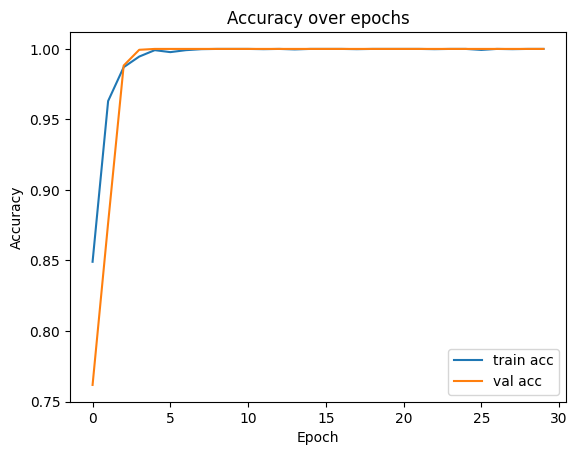

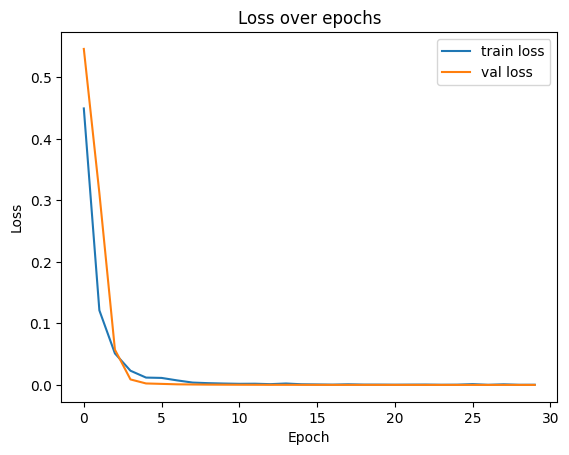

51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step
Confusion Matrix:
 [[275   0   0   0]
 [  0 481   0   0]
 [  0   0 319   0]
 [  0   0   0 537]]
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       275
  meningioma       1.00      1.00      1.00       481
     notumor       1.00      1.00      1.00       319
   pituitary       1.00      1.00      1.00       537

    accuracy                           1.00      1612
   macro avg       1.00      1.00      1.00      1612
weighted avg       1.00      1.00      1.00      1612



In [ ]:
# 1. استيراد المكتبات الأساسية
import os  # عشان نتعامل مع مسارات الفولدر
import numpy as np  # عشان نشتغل على البيانات كـ arrays
import matplotlib.pyplot as plt  # عشان نرسم جرافس للـ loss والـ accuracy
from sklearn.metrics import confusion_matrix, classification_report  # عشان نطلع مصفوفة الخلط والتقرير التفصيلي
import tensorflow as tf  # استيراد تي فـ كيرا لبناء وتدريب الموديل
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # عشان نعمل data augmentation وpreprocessing
from tensorflow.keras.models import Sequential  # عشان نبني الموديل على شكل تسلسلي
from tensorflow.keras.layers import Flatten, Dropout, Dense  # الLayers الأساسية بتاعتنا
from tensorflow.keras.optimizers import Adamax  # الأوبتيميزر اللي هستخدمه
from tensorflow.keras.metrics import Precision, Recall  # المقاييس اللي عايزين نحسبها
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # عشان نعمل callbacks للـ training

# 2. تجهيز مسارات البيانات
base_dir = "/content/drive/MyDrive/archive"  # المسار الرئيسي للداتا
train_dir = os.path.join(base_dir, "/content/drive/MyDrive/archive/Processed_Training")  # فولدر صور التدريب
val_dir   = os.path.join(base_dir, "/content/drive/MyDrive/archive/Processed_Validation")   # فولدر صور الفاليديشن

# 3. تعريف دالة الـ preprocessing لموديل Xception
preprocess_fn = tf.keras.applications.xception.preprocess_input  # دالة التحجيم والتطبيع الخاصة بـ Xception

# 4. إنشاء الـ ImageDataGenerators
datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)  # بنحدد الفانكشن بتاع البري بروسيسنج

train_gen = datagen.flow_from_directory(
    train_dir,            # فولدر التدريب
    target_size=(299,299),# حجم الصور المطلوب
    batch_size=32,        # حجم الـ batch
    class_mode='categorical',# لأن عندنا أكتر من كلاس
    shuffle=True          # عشان نخلط البيانات كل epoch
)

valid_gen = datagen.flow_from_directory(
    val_dir,              # فولدر الفاليديشن
    target_size=(299,299),# نفس الحجم
    batch_size=32,        # نفس الـ batch
    class_mode='categorical',# نفس النوع
    shuffle=False         # مش هنخلط البيانات عشان نعكس الترتيب
)

# 5. بناء الموديل
model = Sequential([
    tf.keras.applications.Xception(
        weights='imagenet',      # نبدأ بالأوزان المتدربة على ImageNet
        include_top=False,       # نشيل الطبقات الأخيرة بتاعة ImageNet
        input_shape=(299,299,3), # شكل الداتا المدخلة
        pooling='avg'            # نعمل average pooling قبل الـ Dense
    ),
    Dropout(0.5),                # بنضيف Dropout عشان نقلل الـ overfitting
    Dense(train_gen.num_classes, activation='softmax')  # طبقة الخرج بعدد الكلاسات
])

# 6. تجميع الموديل (compile)
model.compile(
    optimizer=Adamax(learning_rate=1e-4),  # الأوبتيميزر والـ learning rate
    loss='categorical_crossentropy',      # نوع اللوس لمشكلة التصنيف المتعدد
    metrics=['accuracy', Precision(name='prec'), Recall(name='rec')]  # المقاييس اللي عايزين نتابعها
)

model.summary()  # نطبع ملخص الموديل علشان نتأكد من الأبعاد

# 7. إعداد الـ Callbacks
es = EarlyStopping(
    monitor='val_loss',  # نراقب فقدان الفاليديشن
    patience=5,          # لو مفيش تحسن لمدة 5 epochs يبطل
    restore_best_weights=True  # يرجع أفضل أوزان لحد ما وقف
)
mc = ModelCheckpoint(
    'best_xcep.h5',      # اسم الملف اللي هيتحفظ فيه أحسن موديل
    monitor='val_loss',  # نراقب نفس القيمة
    save_best_only=True  # نحفظ بس أحسن نسخة
)

# 8. تدريب الموديل
history = model.fit(
    train_gen,           # بيانات التدريب
    epochs=30,           # عدد الepochs
    validation_data=valid_gen,  # بيانات الفاليديشن
    callbacks=[es, mc]   # الكولباكس اللي عرفناهم
)

# 9. رسم جرافس التدريب
plt.figure()
plt.plot(history.history['accuracy'], label='train acc')      # جراف دقة التدريب
plt.plot(history.history['val_accuracy'], label='val acc')    # جراف دقة الفاليديشن
plt.title('Accuracy over epochs')                             # عنوان الجراف
plt.xlabel('Epoch')                                           # محور x
plt.ylabel('Accuracy')                                        # محور y
plt.legend()                                                  # الأسطورة
plt.show()                                                    # عرض الجراف

plt.figure()
plt.plot(history.history['loss'], label='train loss')         # جراف لوس التدريب
plt.plot(history.history['val_loss'], label='val loss')       # جراف لوس الفاليديشن
plt.title('Loss over epochs')                                 # عنوان الجراف
plt.xlabel('Epoch')                                           # محور x
plt.ylabel('Loss')                                            # محور y
plt.legend()                                                  # الأسطورة
plt.show()                                                    # عرض الجراف

# 10. التقييم النهائي ومصفوفة الخلط
y_true = valid_gen.classes                    # العلامات الحقيقية
y_prob = model.predict(valid_gen)             # التوقعات اللي طلعها الموديل
y_pred = np.argmax(y_prob, axis=1)            # نحول الاحتمالات لأرقام كلاس

cm = confusion_matrix(y_true, y_pred)         # نحسب مصفوفة الخلط
print('Confusion Matrix:\n', cm)              # نطبع مصفوفة الخلط

labels = list(valid_gen.class_indices.keys()) # نجيب أسماء الكلاسات
print(classification_report(
    y_true, y_pred, target_names=labels       # نطبع التقرير التفصيلي لكل كلاس
))

In [ ]:
import os

# التأكد من وجود المجلد، وإذا مفيش أنشأه
os.makedirs('saved_model', exist_ok=True)

# حفظ النموذج
model.save('saved_model/xception_model.keras')

In [ ]:
model = tf.keras.models.load_model('saved_model/xception_model.keras')

In [ ]:
!pip install flask-cors

In [ ]:
from flask import Flask, request, jsonify
import tensorflow as tf
import numpy as np
from PIL import Image
import time
import random
import os
from flask_cors import CORS

# Load the saved model
model = tf.keras.models.load_model('saved_model/xception_model.keras')

# Class names mapping
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Initialize Flask app
app = Flask(__name__)  # تعريف الـ Flask app هنا
CORS(app)  # Enable CORS for cross-domain requests

# Additional information for tumor types
tumor_info = {
    'glioma': {
        'possible_locations': ['Frontal lobe', 'Temporal lobe', 'Parietal lobe', 'Occipital lobe', 'Brainstem'],
        'possible_sizes': ['1.5 cm', '2.3 cm', '3.1 cm', '2.7 cm', '1.8 cm'],
        'malignancy': ['Potentially malignant', 'High-grade malignant', 'Low-grade malignant']
    },
    'meningioma': {
        'possible_locations': ['Cerebral convexity', 'Parasagittal', 'Sphenoid wing', 'Cerebellopontine angle'],
        'possible_sizes': ['2.1 cm', '3.4 cm', '2.8 cm', '1.9 cm', '2.5 cm'],
        'malignancy': ['Typically benign', 'Potentially atypical']
    },
    'pituitary': {
        'possible_locations': ['Sella turcica', 'Pituitary fossa', 'Suprasellar region'],
        'possible_sizes': ['0.9 cm', '1.3 cm', '1.7 cm', '2.0 cm', '1.5 cm'],
        'malignancy': ['Usually benign', 'Functional', 'Non-functional']
    }
}


# Endpoint for predictions
@app.route('/analyze', methods=['POST'])
def analyze():
    start_time = time.time()

    try:
        # Check if image was uploaded
        if 'image' not in request.files:
            return jsonify({
                'success': False,
                'error': 'No image file provided'
            }), 400

        img_file = request.files['image']
        img = Image.open(img_file).resize((299, 299))

        if img.mode != 'RGB':
            img = img.convert('RGB')

        img_array = np.expand_dims(np.asarray(img) / 255.0, axis=0)

        # Get model predictions
        predictions = model.predict(img_array)
        predicted_class_idx = int(np.argmax(predictions, axis=1)[0])
        confidence = float(predictions[0][predicted_class_idx])
        class_name = class_names[predicted_class_idx]

        # Check if a tumor was detected
        tumor_detected = class_name != 'notumor'

        # Basic response structure
        response = {
            'success': True,
            'prediction': {
                'tumorDetected': tumor_detected,
                'confidence': confidence
            },
            'processingTime': f"{time.time() - start_time:.2f} seconds"
        }

        # Add additional information if a tumor was detected
        if tumor_detected:
            tumor_type = class_name

            # Add tumor type with proper capitalization
            response['prediction']['type'] = tumor_type.capitalize()

            # Add simulated location, size, and malignancy assessment
            if tumor_type in tumor_info:
                info = tumor_info[tumor_type]
                response['prediction']['location'] = random.choice(info['possible_locations'])
                response['prediction']['size'] = random.choice(info['possible_sizes'])
                response['prediction']['malignancy'] = random.choice(info['malignancy'])

        return jsonify(response)

    except Exception as e:
        return jsonify({
            'success': False,
            'error': str(e),
            'processingTime': f"{time.time() - start_time:.2f} seconds"
        }), 500


# Health check endpoint
@app.route('/health', methods=['GET'])
def health_check():
    return jsonify({
        'status': 'online',
        'model': 'Xception Brain Tumor Classifier',
        'classes': class_names
    })


if __name__ == '__main__':
    # Get port from environment variable or use 5000 as default
    port = int(os.environ.get('PORT', 5000))
    app.run(debug=True, host='0.0.0.0', port=port)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
